# Active Inference: Temperature Control

This notebook introduces Active Inference through a concrete example: an agent that infers room temperature.

## The Setup

- **Environment**: A room whose temperature evolves autonomously — `very_cold`, `cold`, `comfortable`, `warm`, `hot`
- **Agent goal**: Track its belief about the current temperature
- **Observation**: Noisy, coarse temperature reading (only 3 levels)

The agent uses Active Inference to *infer* its hidden state from noisy observations. There are no actions — this notebook focuses purely on **perception and belief updating**.

### Key matrices
| Matrix | Meaning |
|--------|---------|
| `A`    | Likelihood: `P(observation \| state)` |
| `B`    | Transition: `P(next_state \| state)` — autonomous dynamics, no actions |
| `C`    | Log preferences over observations |
| `D`    | Prior over initial states |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pymdp.legacy import utils
from pymdp.legacy.agent import Agent

## 1. Define the Generative Model

In [2]:
# States: 0=very_cold, 1=cold, 2=comfortable, 3=warm, 4=hot
# Observations: 3 coarse readings — agent cannot distinguish very_cold from cold,
#               or warm from hot  (partial observability)

num_states = [5]
num_obs    = [3]   # coarser than state space → partially observed

STATE_LABELS = ["very_cold", "cold", "comfortable", "warm", "hot"]
OBS_LABELS   = ["obs:cold", "obs:comfortable", "obs:hot"]

In [3]:
# --- A matrix: likelihood P(obs | state), shape (3 obs × 5 states) ---
# Only 3 coarse observations: the agent cannot tell very_cold from cold,
# or warm from hot — genuine partial observability.
A = utils.initialize_empty_A(num_obs, num_states)
A[0] = np.array([
    #   vc    co    cm    wa    ho   <- true state
    [0.80, 0.60, 0.10, 0.05, 0.00],  # obs=cold
    [0.15, 0.30, 0.70, 0.30, 0.15],  # obs=comfortable
    [0.05, 0.10, 0.20, 0.65, 0.85],  # obs=hot
])

# Verify columns sum to 1
assert np.allclose(A[0].sum(axis=0), 1.0), "A columns must sum to 1"
print("A matrix (partial observations):")
print(np.round(A[0], 2))

A matrix (partial observations):
[[0.8  0.6  0.1  0.05 0.  ]
 [0.15 0.3  0.7  0.3  0.15]
 [0.05 0.1  0.2  0.65 0.85]]


In [4]:
# --- B matrix: autonomous transitions P(s' | s), shape (5 × 5) ---
# Temperature drifts slightly each step — mild mean-reversion toward comfortable.
# No actions: the environment evolves on its own.
B = utils.initialize_empty_B(num_states, [1])  # single "null" action slot

B[0][:, :, 0] = np.array([
    #  vc    co    cm    wa    ho   <- current state
    [0.75, 0.20, 0.05, 0.00, 0.00],
    [0.20, 0.60, 0.15, 0.05, 0.00],
    [0.05, 0.15, 0.60, 0.15, 0.05],
    [0.00, 0.05, 0.15, 0.60, 0.20],
    [0.00, 0.00, 0.05, 0.20, 0.75],
])

assert np.allclose(B[0][:, :, 0].sum(axis=0), 1.0), "B columns must sum to 1"
print("B matrix (autonomous dynamics):")
print(np.round(B[0][:, :, 0], 2))

B matrix (autonomous dynamics):
[[0.75 0.2  0.05 0.   0.  ]
 [0.2  0.6  0.15 0.05 0.  ]
 [0.05 0.15 0.6  0.15 0.05]
 [0.   0.05 0.15 0.6  0.2 ]
 [0.   0.   0.05 0.2  0.75]]


In [5]:
# --- C vector: log preferences over observations (now 3 entries) ---
C = utils.obj_array(1)
C[0] = np.array([-3.0, 5.0, -2.0])  # [cold, comfortable, hot]

# --- D vector: prior over initial states — uniform uncertainty ---
D = utils.obj_array(1)
D[0] = utils.norm_dist(np.ones(5))

print("C (preferences):", C[0])
print("D (initial state prior):", np.round(D[0], 3))

C (preferences): [-3.  5. -2.]
D (initial state prior): [0.2 0.2 0.2 0.2 0.2]


## 2. Instantiate the Agent

In [6]:
agent = Agent(
    A=A, B=B, C=C, D=D,
    inference_algo="VANILLA",
    policy_len=1,
    inference_horizon=1,
    control_fac_idx=None,  # no controllable factors — pure perception
)
print("Agent created.")

Agent created.


## 3. Run a Simulation

In [7]:
def get_observation(true_state: int, A_matrix: np.ndarray) -> int:
    """Sample a noisy observation given the true hidden state."""
    return np.random.choice(len(A_matrix), p=A_matrix[:, true_state])


def step_environment(true_state: int, B_matrix: np.ndarray) -> int:
    """Transition the environment autonomously (no action)."""
    return np.random.choice(B_matrix.shape[0], p=B_matrix[:, true_state, 0])


T = 40
true_state = 0  # start at very_cold

history = {
    "true_state": [],
    "observation": [],
    "belief_comfortable": [],
    "belief_entropy": [],
}

np.random.seed(42)

for t in range(T):
    obs = get_observation(true_state, A[0])
    qs  = agent.infer_states([obs])

    belief  = qs[0]
    entropy = -np.sum(belief * np.log(belief + 1e-8))

    history["true_state"].append(true_state)
    history["observation"].append(obs)
    history["belief_comfortable"].append(float(belief[2]))
    history["belief_entropy"].append(float(entropy))

    true_state = step_environment(true_state, B[0])

print("Simulation complete.")

Simulation complete.


## 4. Visualise Results

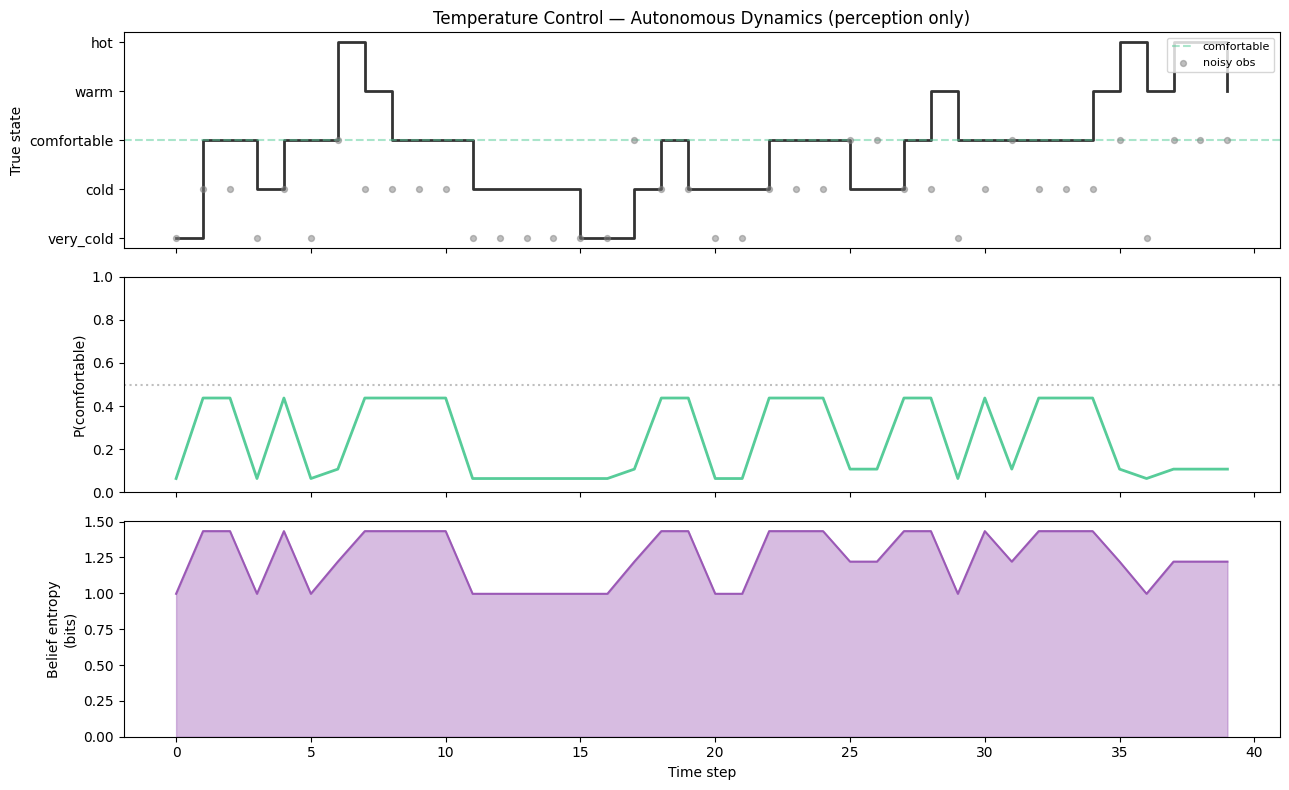

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
t_range = range(T)

state_colors = ["#1a6faf", "#4e9af1", "#57cc99", "#f7c76e", "#f77f6e"]

# --- True state ---
axes[0].step(t_range, history["true_state"], where="post", linewidth=2, color="#333")
axes[0].set_yticks(range(5))
axes[0].set_yticklabels(STATE_LABELS)
axes[0].set_ylabel("True state")
axes[0].set_title("Temperature Control — Autonomous Dynamics (perception only)")
axes[0].axhline(2, color="#57cc99", linestyle="--", alpha=0.5, label="comfortable")
axes[0].scatter(t_range, history["observation"], s=18, color="gray", alpha=0.5, zorder=3, label="noisy obs")
axes[0].legend(loc="upper right", fontsize=8)

# --- Belief in comfortable ---
axes[1].plot(t_range, history["belief_comfortable"], color="#57cc99", linewidth=2)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("P(comfortable)")
axes[1].axhline(0.5, color="gray", linestyle=":", alpha=0.5)

# --- Belief entropy ---
axes[2].fill_between(t_range, history["belief_entropy"], alpha=0.4, color="#9b59b6")
axes[2].plot(t_range, history["belief_entropy"], color="#9b59b6", linewidth=1.5)
axes[2].set_ylabel("Belief entropy\n(bits)")
axes[2].set_ylim(bottom=0)
axes[2].set_xlabel("Time step")

plt.tight_layout()
plt.show()

## 5. Discussion

### What this notebook shows

This is a pure **perception** model — no actions, no policy selection. The agent:
1. Receives a noisy, coarse observation each step
2. Updates its belief over 5 hidden states via variational inference
3. Tracks how certain it is using belief entropy

### Reading the plots

| Panel | What to look for |
|-------|-----------------|
| True state | Autonomous drift — temperature wanders but mean-reverts toward comfortable |
| P(comfortable) | Rises when the agent accumulates consistent "comfortable" observations |
| Belief entropy | High = uncertain; drops when observations are consistent, spikes after jumps |

### Key takeaways
- The A matrix maps 5 states → 3 observations. Adjacent states are easily confused, so the agent needs several steps to localise.
- Entropy spikes when the true state jumps (e.g. very_cold → cold in one step) and the new observations conflict with the prior belief.
- C and D shape the agent's priors but don't drive actions here — they influence the free energy landscape the agent minimises during inference.

### Things to try
- Flatten A columns toward uniform (0.2) and observe how entropy grows and P(comfortable) becomes less responsive.
- Change D to a strong prior on `comfortable` and see how quickly the belief recovers from a cold start.
- In the next notebook we will add actions and show how the same framework extends to active control.